# TB3 - Caso 2: Series de tiempo Airbnb con XGBoost, LightGBM y CatBoost

Este notebook desarrolla el caso de pronostico temporal solicitado para la TB3. Se usa la cantidad mensual de reviews como proxy de demanda o actividad del marketplace, porque el repositorio no contiene reservas reales. La implementacion compara XGBoost, LightGBM y CatBoost bajo un split temporal, sin `train_test_split` aleatorio.

## 1. Comprension del negocio

Airbnb necesita anticipar cambios en la actividad del marketplace para planificar soporte, campanas, gestion de hosts, precios, calidad y capacidad operativa. Como no hay reservas en los datos publicos, se usa el volumen mensual de reviews como indicador observable de actividad posterior a estadias.

La serie no debe interpretarse como reservas exactas. Es una aproximacion razonable para el ejercicio academico y debe comunicarse como limitacion.

In [2]:
from pathlib import Path
import math
import os
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "data").exists() and (candidate / "pyproject.toml").exists():
            return candidate
    return start

PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)

DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIG_DIR = OUTPUT_DIR / "figures"
MODEL_DIR = OUTPUT_DIR / "models"
for directory in [OUTPUT_DIR, FIG_DIR, MODEL_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print(f"Proyecto: {PROJECT_ROOT}")

Proyecto: c:\Development\ANALISISEMPRESAR-DATASCIENCE-AIRBNB\AirBnB-Analisis-Empresarial


## 2. Comprension de los datos

Se identifican fuentes temporales. La prioridad es `reviews` con una columna de fecha (`review_date`, `date` u otra equivalente). Si no existiera, el notebook intentaria usar `calendar` o fechas disponibles en listings, aunque en este proyecto se encontro `reviews.parquet`.

In [3]:
def discover_data_files(base_dir: Path) -> pd.DataFrame:
    patterns = ["*.csv", "*.csv.gz", "*.parquet", "*.xlsx", "*.xls"]
    rows = []
    for pattern in patterns:
        for path in base_dir.rglob(pattern):
            rows.append({
                "path": path.relative_to(PROJECT_ROOT).as_posix(),
                "name": path.name,
                "suffix": "".join(path.suffixes),
                "size_mb": round(path.stat().st_size / (1024 ** 2), 2),
            })
    return pd.DataFrame(rows).sort_values("path").reset_index(drop=True)

available_files = discover_data_files(DATA_DIR)
display(available_files)

,path,name,suffix,size_mb
0,data/bronze/listings_bronze.parquet,listings_bronze.parquet,.parquet,86.75
1,data/bronze/reviews_bronze.parquet,reviews_bronze.parquet,.parquet,852.88
2,data/gold/analytics/listing_trust_risk.csv,listing_trust_risk.csv,.csv,49.19
3,data/gold/analytics/listing_trust_risk.parquet,listing_trust_risk.parquet,.parquet,7.72
4,data/gold/analytics/market_trust_risk_summary.csv,market_trust_risk_summary.csv,.csv,0.00
5,data/gold/analytics/market_trust_risk_summary....,market_trust_risk_summary.parquet,.parquet,0.01
6,data/gold/analytics/risk_segment_summary.csv,risk_segment_summary.csv,.csv,0.00
7,data/gold/analytics/risk_segment_summary.parquet,risk_segment_summary.parquet,.parquet,0.00
8,data/gold/listings.csv,listings.csv,.csv,98.74
9,data/gold/listings.parquet,listings.parquet,.parquet,36.74


In [4]:
def first_existing(paths):
    for path in paths:
        path = PROJECT_ROOT / path
        if path.exists():
            return path
    return None

def read_table(path: Path, columns=None) -> pd.DataFrame:
    suffixes = "".join(path.suffixes).lower()
    if suffixes.endswith(".parquet"):
        return pd.read_parquet(path, columns=columns)
    if suffixes.endswith(".csv") or suffixes.endswith(".csv.gz"):
        return pd.read_csv(path, usecols=columns)
    if suffixes.endswith(".xlsx") or suffixes.endswith(".xls"):
        return pd.read_excel(path, usecols=columns)
    raise ValueError(f"Formato no soportado: {path}")

reviews_path = first_existing([
    "data/gold/reviews.parquet",
    "data/silver/reviews.parquet",
    "data/raw/reviews.csv.gz",
])
calendar_path = first_existing([
    "data/gold/calendar.parquet",
    "data/silver/calendar.parquet",
    "data/raw/calendar.csv.gz",
])
listings_path = first_existing([
    "data/gold/listings.parquet",
    "data/silver/listings.parquet",
    "data/raw/listings.csv.gz",
])

print("Reviews:", reviews_path.relative_to(PROJECT_ROOT) if reviews_path else "No encontrado")
print("Calendar:", calendar_path.relative_to(PROJECT_ROOT) if calendar_path else "No encontrado")
print("Listings:", listings_path.relative_to(PROJECT_ROOT) if listings_path else "No encontrado")

Reviews: data\gold\reviews.parquet
Calendar: No encontrado
Listings: data\gold\listings.parquet


In [5]:
def table_columns(path: Path):
    suffixes = "".join(path.suffixes).lower()
    if suffixes.endswith(".parquet"):
        import pyarrow.parquet as pq

        return pq.ParquetFile(path).schema.names
    if suffixes.endswith(".csv") or suffixes.endswith(".csv.gz"):
        return pd.read_csv(path, nrows=5).columns.tolist()
    return read_table(path).columns.tolist()

source_name = None
temporal_df = None
date_col = None
metric_description = None

if reviews_path is not None:
    review_cols_all = table_columns(reviews_path)
    date_candidates = ["review_date", "date", "reviewed_at", "created_at"]
    date_col = next((c for c in date_candidates if c in review_cols_all), None)
    if date_col is not None:
        cols = [c for c in ["listing_id", date_col] if c in review_cols_all]
        temporal_df = read_table(reviews_path, columns=cols)
        source_name = reviews_path.relative_to(PROJECT_ROOT).as_posix()
        metric_description = "Cantidad mensual de reviews como proxy de demanda/actividad"

if temporal_df is None and calendar_path is not None:
    calendar_cols_all = table_columns(calendar_path)
    date_candidates = ["date", "calendar_date", "scraped_date"]
    date_col = next((c for c in date_candidates if c in calendar_cols_all), None)
    if date_col is not None:
        cols = [c for c in ["listing_id", date_col, "available", "price"] if c in calendar_cols_all]
        temporal_df = read_table(calendar_path, columns=cols)
        source_name = calendar_path.relative_to(PROJECT_ROOT).as_posix()
        metric_description = "Actividad mensual derivada de calendar"

if temporal_df is None:
    raise FileNotFoundError("No se encontro una fuente temporal con columna de fecha usable.")

temporal_df[date_col] = pd.to_datetime(temporal_df[date_col], errors="coerce")
temporal_df = temporal_df.dropna(subset=[date_col])

print("Fuente temporal:", source_name)
print("Columna fecha:", date_col)
print("Shape temporal:", temporal_df.shape)
print("Periodo:", temporal_df[date_col].min(), "a", temporal_df[date_col].max())
display(temporal_df.head(3))

Fuente temporal: data/gold/reviews.parquet
Columna fecha: review_date
Shape temporal: (5361259, 2)
Periodo: 2010-06-07 00:00:00 a 2026-02-14 00:00:00


,listing_id,review_date
0,2992450,2014-07-01
1,2992450,2014-10-24
2,2992450,2015-03-04


## 3. Preparacion de los datos

La serie se agrega a frecuencia mensual (`MS`, inicio de mes). Para reviews, `y` es el numero de reviews por mes. Luego se generan variables calendario, rezagos y medias/volatilidades moviles con `shift(1)` para evitar leakage: cada mes solo usa informacion de meses previos.

In [6]:
def save_current_fig(filename: str):
    path = FIG_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    print(f"Figura guardada: {path.relative_to(PROJECT_ROOT)}")

if "review" in source_name.lower():
    monthly = (
        temporal_df.set_index(date_col)
        .sort_index()
        .resample("MS")
        .size()
        .rename("monthly_reviews")
        .to_frame()
    )
    target_col = "monthly_reviews"
else:
    temp = temporal_df.set_index(date_col).sort_index()
    if "available" in temp.columns:
        available = temp["available"].astype(str).str.lower().isin(["t", "true", "1", "yes"])
        monthly = available.resample("MS").sum().rename("monthly_available_units").to_frame()
        target_col = "monthly_available_units"
    elif "price" in temp.columns:
        price = temp["price"].astype(str).str.replace(r"[$,]", "", regex=True).astype(float)
        monthly = price.resample("MS").mean().rename("monthly_avg_price").to_frame()
        target_col = "monthly_avg_price"
    else:
        monthly = temp.resample("MS").size().rename("monthly_records").to_frame()
        target_col = "monthly_records"

full_index = pd.date_range(monthly.index.min(), monthly.index.max(), freq="MS")
monthly = monthly.reindex(full_index)
if target_col.startswith("monthly_reviews") or target_col.endswith("records"):
    monthly[target_col] = monthly[target_col].fillna(0)
else:
    monthly[target_col] = monthly[target_col].interpolate(limit_direction="both")
monthly.index.name = "month"

display(monthly.head())
display(monthly.tail())
print("Meses:", len(monthly), "| faltantes en y:", int(monthly[target_col].isna().sum()))

,monthly_reviews
month,
2010-06-01,1
2010-07-01,1
2010-08-01,3
2010-09-01,4
2010-10-01,7


,monthly_reviews
month,
2025-10-01,28224
2025-11-01,23048
2025-12-01,6355
2026-01-01,378
2026-02-01,104


Meses: 189 | faltantes en y: 0


Figura guardada: outputs\figures\ts_monthly_series.png


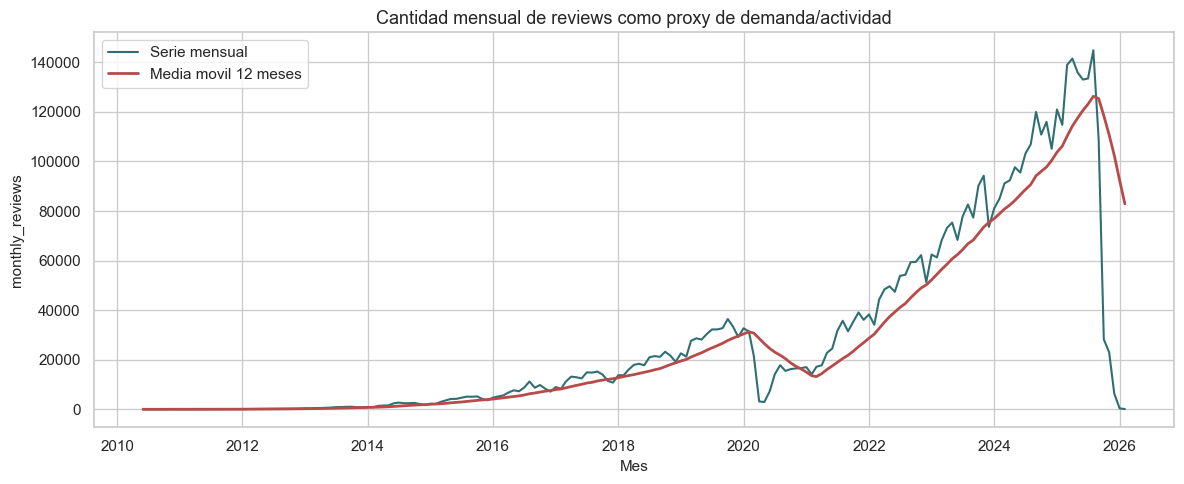

Figura guardada: outputs\figures\ts_monthly_seasonality_boxplot.png


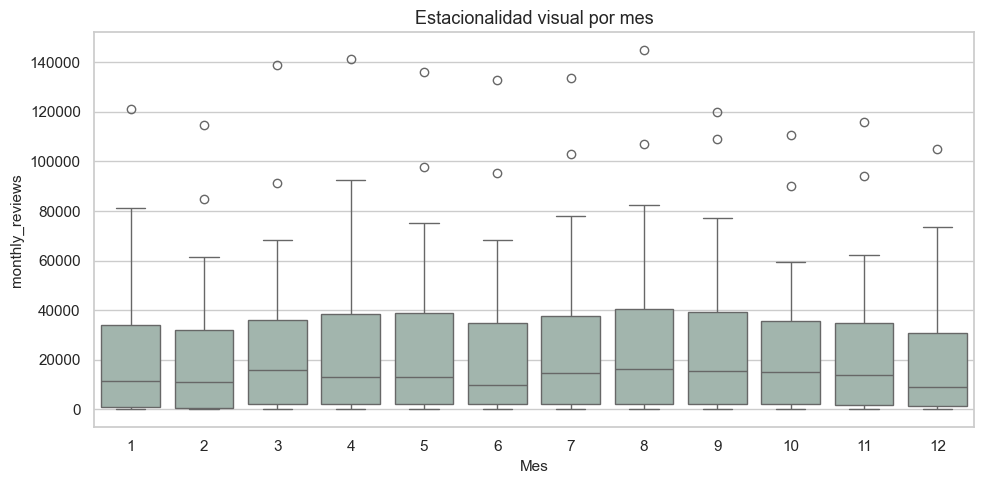

In [7]:
monthly["rolling_12"] = monthly[target_col].rolling(12, min_periods=1).mean()
plt.figure(figsize=(12, 5))
plt.plot(monthly.index, monthly[target_col], color="#2f6f73", label="Serie mensual")
plt.plot(monthly.index, monthly["rolling_12"], color="#b84a4a", linewidth=2, label="Media movil 12 meses")
plt.title(metric_description)
plt.xlabel("Mes")
plt.ylabel(target_col)
plt.legend()
save_current_fig("ts_monthly_series.png")
plt.show()

month_box = monthly.copy()
month_box["month_num"] = month_box.index.month
plt.figure(figsize=(10, 5))
sns.boxplot(data=month_box, x="month_num", y=target_col, color="#9fb8ad")
plt.title("Estacionalidad visual por mes")
plt.xlabel("Mes")
plt.ylabel(target_col)
save_current_fig("ts_monthly_seasonality_boxplot.png")
plt.show()

monthly = monthly.drop(columns=["rolling_12"])

In [8]:
ts = monthly.copy()
ts["year"] = ts.index.year
ts["month"] = ts.index.month
ts["quarter"] = ts.index.quarter
ts["time_idx"] = np.arange(len(ts))
ts["month_sin"] = np.sin(2 * np.pi * ts["month"] / 12)
ts["month_cos"] = np.cos(2 * np.pi * ts["month"] / 12)

for lag in [1, 2, 3, 6, 12]:
    ts[f"lag_{lag}"] = ts[target_col].shift(lag)

shifted_y = ts[target_col].shift(1)
ts["rolling_mean_3"] = shifted_y.rolling(3).mean()
ts["rolling_mean_6"] = shifted_y.rolling(6).mean()
ts["rolling_std_3"] = shifted_y.rolling(3).std()

supervised = ts.dropna().copy()
feature_cols = [c for c in supervised.columns if c != target_col]

print("Shape supervisado:", supervised.shape)
print("Features:", feature_cols)
display(supervised.head())

Shape supervisado: (177, 15)
Features: ['year', 'month', 'quarter', 'time_idx', 'month_sin', 'month_cos', 'lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12', 'rolling_mean_3', 'rolling_mean_6', 'rolling_std_3']


,monthly_reviews,year,month,quarter,time_idx,month_sin,month_cos,lag_1,lag_2,lag_3,lag_6,lag_12,rolling_mean_3,rolling_mean_6,rolling_std_3
month,,,,,,,,,,,,,,,
2011-06-01,20,2011,6,2,12,1.224647e-16,-1.000000e+00,12.0,11.0,14.0,8.0,1.0,12.333333,9.166667,1.527525
2011-07-01,33,2011,7,3,13,-5.000000e-01,-8.660254e-01,20.0,12.0,11.0,7.0,1.0,14.333333,11.166667,4.932883
2011-08-01,30,2011,8,3,14,-8.660254e-01,-5.000000e-01,33.0,20.0,12.0,3.0,3.0,21.666667,15.500000,10.598742
2011-09-01,46,2011,9,3,15,-1.000000e+00,-1.836970e-16,30.0,33.0,20.0,14.0,4.0,27.666667,20.000000,6.806859
2011-10-01,43,2011,10,4,16,-8.660254e-01,5.000000e-01,46.0,30.0,33.0,11.0,7.0,36.333333,25.333333,8.504901


## 4. Modelado

Se usa un split temporal: los ultimos meses quedan como test. Se comparan tres modelos de gradient boosting para regresion: XGBoost, LightGBM y CatBoost. Si alguna libreria no esta instalada, el notebook registra el error y continua con las demas.

Train: 2011-06-01 a 2023-02-01 (141, 15)
Test: 2023-03-01 a 2026-02-01 (36, 15)
Figura guardada: outputs\figures\ts_train_test_split.png


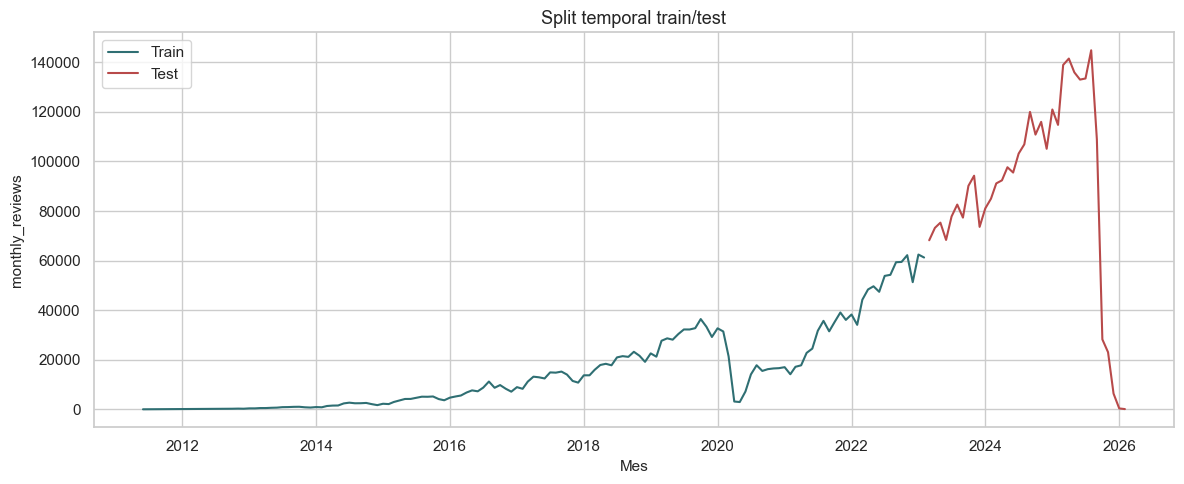

In [9]:
if len(supervised) < 24:
    raise ValueError("La serie supervisada tiene menos de 24 meses utiles; no es suficiente para este ejercicio.")

test_size = max(6, int(math.ceil(len(supervised) * 0.20)))
train = supervised.iloc[:-test_size].copy()
test = supervised.iloc[-test_size:].copy()

X_train = train[feature_cols]
y_train = train[target_col]
X_test = test[feature_cols]
y_test = test[target_col]

print("Train:", train.index.min().date(), "a", train.index.max().date(), train.shape)
print("Test:", test.index.min().date(), "a", test.index.max().date(), test.shape)

plt.figure(figsize=(12, 5))
plt.plot(train.index, y_train, label="Train", color="#2f6f73")
plt.plot(test.index, y_test, label="Test", color="#b84a4a")
plt.title("Split temporal train/test")
plt.xlabel("Mes")
plt.ylabel(target_col)
plt.legend()
save_current_fig("ts_train_test_split.png")
plt.show()

In [10]:
model_specs = {}
import_errors = {}

try:
    from xgboost import XGBRegressor

    model_specs["XGBoost"] = XGBRegressor(
        n_estimators=350,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
except Exception as exc:
    import_errors["XGBoost"] = repr(exc)

try:
    from lightgbm import LGBMRegressor

    model_specs["LightGBM"] = LGBMRegressor(
        n_estimators=350,
        learning_rate=0.05,
        num_leaves=15,
        min_child_samples=5,
        random_state=RANDOM_STATE,
        verbosity=-1,
    )
except Exception as exc:
    import_errors["LightGBM"] = repr(exc)

try:
    from catboost import CatBoostRegressor

    model_specs["CatBoost"] = CatBoostRegressor(
        iterations=350,
        learning_rate=0.05,
        depth=4,
        loss_function="RMSE",
        random_seed=RANDOM_STATE,
        verbose=False,
        allow_writing_files=False,
    )
except Exception as exc:
    import_errors["CatBoost"] = repr(exc)

if import_errors:
    print("Librerias no disponibles:")
    for name, error in import_errors.items():
        print(name, error)

if not model_specs:
    raise ImportError("No hay modelos disponibles. Instalar xgboost, lightgbm o catboost.")

In [11]:
def smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    mask = denominator != 0
    if not mask.any():
        return 0.0
    return float(np.mean(np.abs(y_true[mask] - y_pred[mask]) / denominator[mask]) * 100)

trained_models = {}
predictions = {}
metrics_rows = []

for model_name, model in model_specs.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred = np.maximum(y_pred, 0)
    predictions[model_name] = pd.Series(y_pred, index=y_test.index, name=model_name)
    trained_models[model_name] = model
    metrics_rows.append({
        "model": model_name,
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": float(np.sqrt(mean_squared_error(y_test, y_pred))),
        "SMAPE": smape(y_test, y_pred),
        "R2": r2_score(y_test, y_pred),
        "train_months": len(train),
        "test_months": len(test),
        "train_start": train.index.min().date().isoformat(),
        "train_end": train.index.max().date().isoformat(),
        "test_start": test.index.min().date().isoformat(),
        "test_end": test.index.max().date().isoformat(),
        "target": target_col,
        "source": source_name,
    })

metrics_ts = pd.DataFrame(metrics_rows).sort_values(["RMSE", "SMAPE"], ascending=[True, True]).reset_index(drop=True)
metrics_path = OUTPUT_DIR / "metrics_series_tiempo.csv"
metrics_ts.to_csv(metrics_path, index=False)
display(metrics_ts)
print(f"Metricas guardadas: {metrics_path.relative_to(PROJECT_ROOT)}")

best_model_name = metrics_ts.iloc[0]["model"]
best_model = trained_models[best_model_name]
print("Mejor modelo por RMSE:", best_model_name)

,model,MAE,RMSE,SMAPE,R2,train_months,test_months,train_start,train_end,test_start,test_end,target,source
0,XGBoost,38941.167969,44779.143717,60.030836,-0.382010,141,36,2011-06-01,2023-02-01,2023-03-01,2026-02-01,monthly_reviews,data/gold/reviews.parquet
1,LightGBM,38765.003152,45320.148246,57.115061,-0.415605,141,36,2011-06-01,2023-02-01,2023-03-01,2026-02-01,monthly_reviews,data/gold/reviews.parquet
2,CatBoost,40961.149887,46540.359546,62.598355,-0.492859,141,36,2011-06-01,2023-02-01,2023-03-01,2026-02-01,monthly_reviews,data/gold/reviews.parquet


Metricas guardadas: outputs\metrics_series_tiempo.csv
Mejor modelo por RMSE: XGBoost


## 5. Evaluacion

Se comparan MAE, RMSE, SMAPE y R2. El criterio principal de seleccion es menor RMSE, con SMAPE como lectura relativa. Al tratarse de una serie agregada mensual, los errores se interpretan como diferencia en cantidad de reviews mensuales proxy.

,XGBoost,LightGBM,CatBoost,real
month,,,,
2023-03-01,61241.808594,59683.225600,57650.228823,68223
2023-04-01,60644.097656,60482.237521,58593.752917,73211
2023-05-01,60950.925781,59980.841014,57572.558469,75319
2023-06-01,60074.339844,59570.468035,58981.443740,68352
2023-07-01,61177.109375,61648.510942,59801.482077,77809


Figura guardada: outputs\figures\ts_real_vs_predicted_models.png


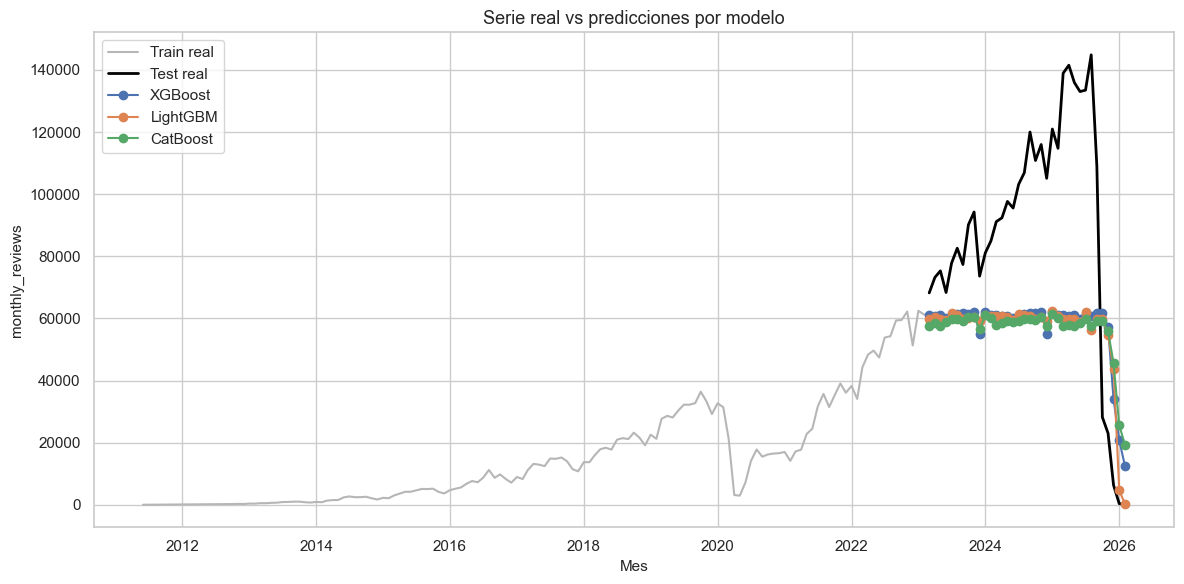

Figura guardada: outputs\figures\ts_metrics_comparison.png


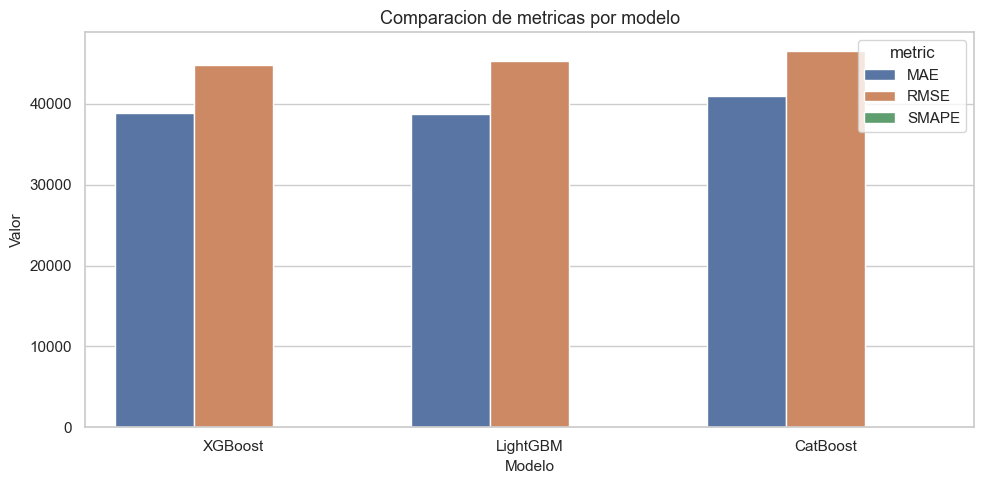

Figura guardada: outputs\figures\ts_residuals_best_model.png


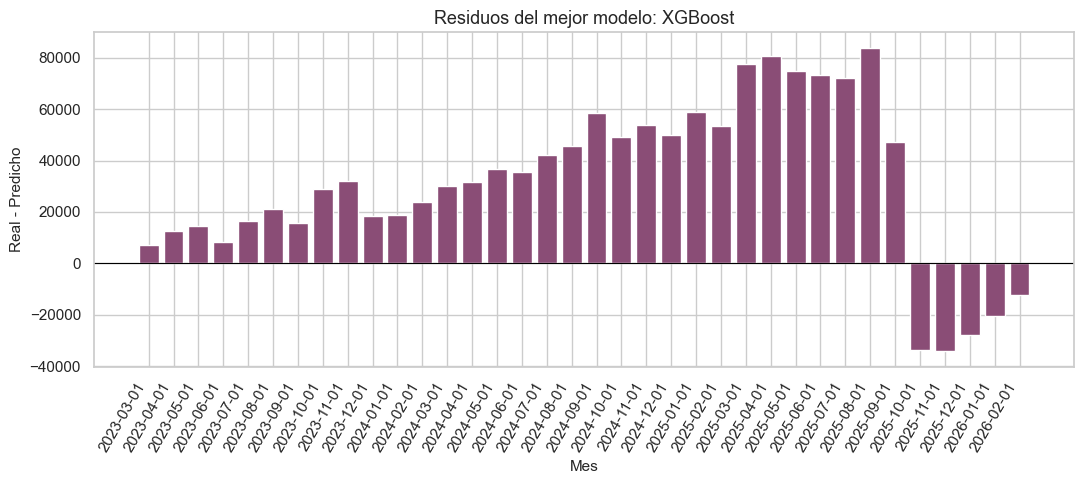

In [12]:
pred_df = pd.concat(predictions.values(), axis=1)
pred_df["real"] = y_test
display(pred_df.head())

plt.figure(figsize=(12, 6))
plt.plot(train.index, y_train, color="#b6b6b6", label="Train real")
plt.plot(test.index, y_test, color="black", linewidth=2, label="Test real")
for model_name in predictions:
    plt.plot(predictions[model_name].index, predictions[model_name], marker="o", label=model_name)
plt.title("Serie real vs predicciones por modelo")
plt.xlabel("Mes")
plt.ylabel(target_col)
plt.legend()
save_current_fig("ts_real_vs_predicted_models.png")
plt.show()

metric_plot = metrics_ts.melt(id_vars="model", value_vars=["MAE", "RMSE", "SMAPE"], var_name="metric", value_name="value")
plt.figure(figsize=(10, 5))
sns.barplot(data=metric_plot, x="model", y="value", hue="metric")
plt.title("Comparacion de metricas por modelo")
plt.xlabel("Modelo")
plt.ylabel("Valor")
save_current_fig("ts_metrics_comparison.png")
plt.show()

residuals = y_test - predictions[best_model_name]
plt.figure(figsize=(11, 5))
plt.axhline(0, color="black", linewidth=0.8)
plt.bar(residuals.index.astype(str), residuals.values, color="#8a4d76")
plt.xticks(rotation=60, ha="right")
plt.title(f"Residuos del mejor modelo: {best_model_name}")
plt.xlabel("Mes")
plt.ylabel("Real - Predicho")
save_current_fig("ts_residuals_best_model.png")
plt.show()

,feature,importance
6,lag_1,0.584701
11,rolling_mean_3,0.289223
3,time_idx,0.074257
7,lag_2,0.019778
0,year,0.010278
10,lag_12,0.006975
9,lag_6,0.005315
4,month_sin,0.002476
8,lag_3,0.002006
13,rolling_std_3,0.001456


Figura guardada: outputs\figures\ts_feature_importance_best_model.png


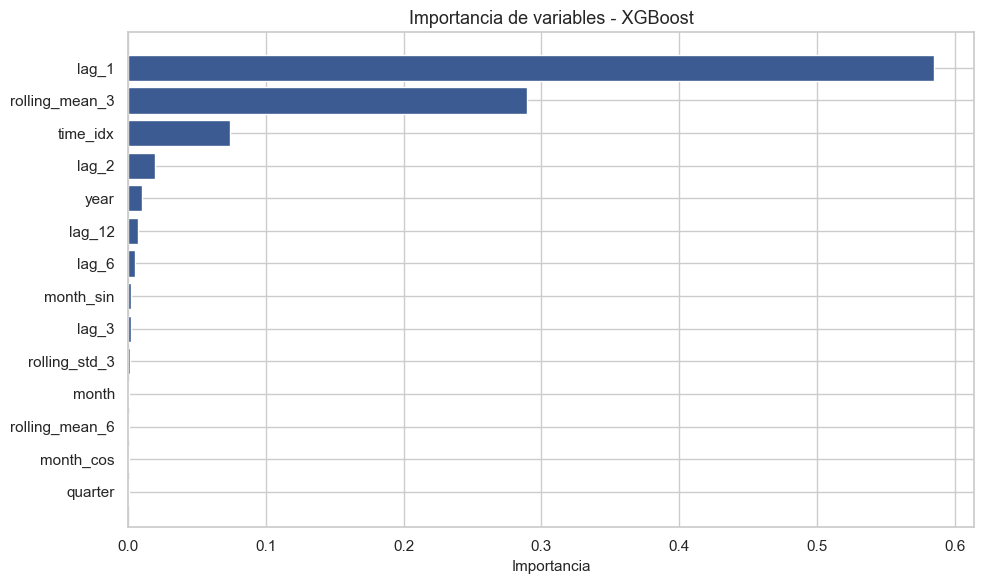

Importancias guardadas: outputs\feature_importance_series_tiempo.csv


In [13]:
if hasattr(best_model, "feature_importances_"):
    importance = pd.DataFrame({
        "feature": feature_cols,
        "importance": best_model.feature_importances_,
    }).sort_values("importance", ascending=False)
else:
    importance = pd.DataFrame({"feature": feature_cols, "importance": np.nan})

importance_path = OUTPUT_DIR / "feature_importance_series_tiempo.csv"
importance.to_csv(importance_path, index=False)
display(importance.head(15))

top_importance = importance.head(15).sort_values("importance")
plt.figure(figsize=(10, 6))
plt.barh(top_importance["feature"], top_importance["importance"], color="#3b5b92")
plt.title(f"Importancia de variables - {best_model_name}")
plt.xlabel("Importancia")
save_current_fig("ts_feature_importance_best_model.png")
plt.show()
print(f"Importancias guardadas: {importance_path.relative_to(PROJECT_ROOT)}")

In [14]:
model_artifact = {
    "model_name": best_model_name,
    "model": best_model,
    "features": feature_cols,
    "target": target_col,
    "source": source_name,
    "metric_description": metric_description,
    "train_start": train.index.min().date().isoformat(),
    "train_end": train.index.max().date().isoformat(),
    "test_start": test.index.min().date().isoformat(),
    "test_end": test.index.max().date().isoformat(),
    "metrics": metrics_ts.to_dict(orient="records"),
}
model_path = MODEL_DIR / "best_timeseries_model.pkl"
joblib.dump(model_artifact, model_path)
print(f"Modelo guardado: {model_path.relative_to(PROJECT_ROOT)}")

Modelo guardado: outputs\models\best_timeseries_model.pkl


## 6. Implementacion

El forecast de actividad mensual puede integrarse al dashboard de confianza/riesgo para anticipar picos de soporte, necesidad de revision de hosts, campanas de calidad o capacidad operativa. Tambien puede combinarse con segmentos de riesgo: si se espera alta actividad en un mercado con muchos listings `High`, Trust & Safety puede adelantar acciones preventivas.

In [15]:
def fmt_metric(value, decimals=4):
    if pd.isna(value):
        return "N/D"
    return f"{value:.{decimals}f}"

reg_metrics_path = OUTPUT_DIR / "metrics_regresion_logistica.csv"
if reg_metrics_path.exists():
    reg_metrics = pd.read_csv(reg_metrics_path)
    best_reg = reg_metrics.sort_values(["f1", "roc_auc"], ascending=False).iloc[0]
else:
    reg_metrics = pd.DataFrame()
    best_reg = pd.Series(dtype="object")

best_ts = metrics_ts.iloc[0]
period_start = monthly.index.min().date().isoformat()
period_end = monthly.index.max().date().isoformat()

summary_lines = [
    "# TB3 - Resumen ejecutivo de resultados Airbnb",
    "",
    "## 1. Caso de uso seleccionado",
    "",
    "Se desarrollo un caso de analitica empresarial para Airbnb orientado al **Dashboard de Confianza y Riesgo de Listings**. El objetivo es priorizar listings con menor confianza operacional y anticipar la actividad mensual del marketplace para apoyar Trust & Safety, Operaciones, Producto y Compliance.",
    "",
    "## 2. Regresion logistica",
    "",
    "- **Objetivo:** clasificar listings con mayor riesgo o menor confianza operacional mediante `high_risk_listing`.",
    "- **Variable objetivo:** proxy academica basada en `risk_segment` High/Critical del mart `listing_trust_risk` cuando esta disponible. No representa disputas reales internas.",
    "- **Principales variables utilizadas:** precio, disponibilidad, rating, numero de reviews, reviews por mes, senales del host, capacidad, reglas de estancia, ubicacion, tipo de propiedad, tipo de habitacion y longitudes de texto del listing.",
    f"- **Mejor modelo:** {best_reg.get('model', 'N/D')}.",
    f"- **Metricas obtenidas:** accuracy={fmt_metric(best_reg.get('accuracy', np.nan))}, precision={fmt_metric(best_reg.get('precision', np.nan))}, recall={fmt_metric(best_reg.get('recall', np.nan))}, F1={fmt_metric(best_reg.get('f1', np.nan))}, ROC-AUC={fmt_metric(best_reg.get('roc_auc', np.nan))}.",
    "- **Interpretacion de negocio:** el modelo permite priorizar revision operativa de listings con senales de baja confianza, especialmente cuando se combina con explicabilidad por coeficientes y segmentacion por mercado.",
    "- **Limitaciones:** las metricas se calculan contra una etiqueta proxy. Para afirmar precision real o reduccion de disputas se requieren reservas, disputas, soporte y snapshots previos a la primera reserva.",
    "",
    "## 3. Series de tiempo",
    "",
    f"- **Metrica pronosticada:** {metric_description} (`{target_col}`).",
    f"- **Periodo analizado:** {period_start} a {period_end}.",
    f"- **Modelos comparados:** {', '.join(metrics_ts['model'].tolist())}.",
    f"- **Mejor modelo:** {best_ts['model']} por menor RMSE.",
    f"- **Metricas obtenidas:** MAE={fmt_metric(best_ts['MAE'], 2)}, RMSE={fmt_metric(best_ts['RMSE'], 2)}, SMAPE={fmt_metric(best_ts['SMAPE'], 2)}%, R2={fmt_metric(best_ts['R2'], 4)}.",
    "- **Interpretacion de negocio:** el forecast ayuda a anticipar meses con mayor actividad observable, ajustar capacidad de soporte, preparar campanas de calidad y priorizar mercados antes de picos de demanda.",
    "- **Limitaciones:** reviews no equivalen a reservas. Los ultimos meses pueden estar incompletos por fecha de corte de los datos y la serie agrega mercados heterogeneos.",
    "",
    "## 4. Implementacion propuesta",
    "",
    "- Integrar la probabilidad de `high_risk_listing` al dashboard como score predictivo complementario al `risk_score` explicable.",
    "- Usar el forecast mensual para planificar capacidad operativa, soporte y campanas de mejora de calidad.",
    "- Trust & Safety podria priorizar revision manual de listings de alto riesgo en meses o mercados con alta actividad prevista.",
    "- Operaciones podria monitorear desviaciones entre actividad real y pronosticada para ajustar recursos.",
    "- Producto y Compliance podrian usar las explicaciones del modelo para mejorar flujos de verificacion, contenido del anuncio y cumplimiento local.",
    "",
    "## 5. Conclusion final alineada a CRISP-DM",
    "",
    "La TB3 implementa dos casos practicos y ejecutables bajo CRISP-DM. La regresion logistica aborda la priorizacion de riesgo a nivel de listing y la serie de tiempo estima actividad mensual del marketplace. Ambos casos son utiles para decision empresarial, pero sus resultados deben presentarse como evidencia academica sobre datos publicos y no como medicion real de disputas internas de Airbnb.",
]
summary = "\n".join(summary_lines) + "\n"

summary_path = OUTPUT_DIR / "tb3_resumen_resultados.md"
summary_path.write_text(summary, encoding="utf-8")
print(f"Resumen guardado: {summary_path.relative_to(PROJECT_ROOT)}")
print(summary[:1200])

Resumen guardado: outputs\tb3_resumen_resultados.md
# TB3 - Resumen ejecutivo de resultados Airbnb

## 1. Caso de uso seleccionado

Se desarrollo un caso de analitica empresarial para Airbnb orientado al **Dashboard de Confianza y Riesgo de Listings**. El objetivo es priorizar listings con menor confianza operacional y anticipar la actividad mensual del marketplace para apoyar Trust & Safety, Operaciones, Producto y Compliance.

## 2. Regresion logistica

- **Objetivo:** clasificar listings con mayor riesgo o menor confianza operacional mediante `high_risk_listing`.
- **Variable objetivo:** proxy academica basada en `risk_segment` High/Critical del mart `listing_trust_risk` cuando esta disponible. No representa disputas reales internas.
- **Principales variables utilizadas:** precio, disponibilidad, rating, numero de reviews, reviews por mes, senales del host, capacidad, reglas de estancia, ubicacion, tipo de propiedad, tipo de habitacion y longitudes de texto del listing.
- **Mejor mo